In [1]:
import os
import torch
from torchvision import datasets
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn.functional as F
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
from dataclasses import dataclass
from torch.nn.functional import mse_loss, binary_cross_entropy_with_logits
from lib.models.base import VAEOutput

from pathlib import Path
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import pairwise_distances, confusion_matrix
from sklearn.decomposition import PCA

from lib.data.utils import Color
from lib.data.datasets import (
    ColoredMNISTDataset,
    get_ColoredMNISTDataset_dataloader
)
from lib.models import (
    EncoderDownM, DecoderUpM,
    CVAE, CVAEFilm,
    AEModelConfig,
    ConfigBetaVAEForEmbedding, BetaVAEForEmbedding
)
from lib.plotting.fonts import montserrat_regular, montserrat_medium, montserrat_bold
from lib.analysis import tg_mds
from lib.plotting import fig_to_rgba
from lib import filepaths

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


##### Utils

In [4]:
def sample_trial(n):
    X = test_dataset.X
    x = X[np.random.randint(0,X.shape[0], (n,))]
    return x

@torch.no_grad()
def get_latent(model, x):
    model.eval()
    x = torch.tensor(x, device=device)
    mu, logvar = model.encode(x)
    z = model._reparameterize(mu, logvar)
    rec = model.decode(z)
    return rec.cpu().numpy()

def load_model(ckpt):
    model = BetaVAEForEmbedding(ckpt["config"])
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()
    return model

In [10]:
color_codes = [Color.RED, Color.GREEN, Color.CYAN, Color.YELLOW, Color.MAGENTA]

train_dataset = ColoredMNISTDataset(color_codes=color_codes, resize=32, train=True)
test_dataset = ColoredMNISTDataset(color_codes=color_codes, resize=32, train=False)

train_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=64,
    dataset=train_dataset,
    drop_last=False, shuffle=True
)

test_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=64,
    dataset=test_dataset,
    drop_last=False, shuffle=False
)

###

class EmbedDataset(Dataset):
    def __init__(self, X):
        self.X = X

    def __len__(self): return self.X.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]).float()

ckpt = torch.load("resources/ckpt_cvae_film_basic.pt", weights_only=False)

cvae = CVAEFilm(
    config=ckpt["config"],
    **ckpt["kwargs"]
) 
cvae.load_state_dict(ckpt["state_dict"])
cvae.to(device)
cvae.eval()
cvae.show_number_of_parameters()

@torch.no_grad()
def get_embedding(cvae, pixel_values, label_ids, feature_ids):
    cvae.eval()
    sem_embed = cvae.sem_embeddings(label_ids)
    feat_embed = cvae.feat_embeddings(feature_ids)
    mu, _ = cvae.encode(pixel_values)
    
    embed = torch.cat([mu.flatten(1), sem_embed, feat_embed], dim=-1)
    return embed.cpu().numpy()

# TRAIN SET
hs = []
for batch in tqdm(train_dataloader):
    batch.to(device)
    h = get_embedding(cvae, batch.pixel_values, batch.label_ids, batch.feature_ids)
    hs.append(h) 
train_dataset = EmbedDataset(np.vstack(hs))
# TEST SET
hs = []
for batch in tqdm(test_dataloader):
    batch.to(device)
    h = get_embedding(cvae, batch.pixel_values, batch.label_ids, batch.feature_ids)
    hs.append(h)
test_dataset = EmbedDataset(np.vstack(hs))

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)

0.561M / 0.561M


100%|██████████| 157/157 [00:03<00:00, 50.48it/s]


In [11]:
root = "resources/beta_vae_capacity.pt"
ckpts = torch.load(root, weights_only=False)

Cs = [0,1,2,4,8]
colors = ["#414a69", "#b04151", "#d28750", "#7dafb8", "#429867"]
palette = {k:v for k,v in zip(Cs, colors)}

In [19]:
k = 3
Ns = [5, 10, 25, 50, 100, 200]

data = []
for C in Cs:
    k_model = load_model(ckpts[C])

    for N in tqdm(Ns):
        for _ in range(1000):
            stimuli = sample_trial(N)
            target = np.random.choice(N)
            query = stimuli[target]

            q = query[None]
            keys = get_latent(k_model, stimuli)

            dist = pairwise_distances(q, keys, metric="cosine")[0]
            top_k = np.argsort(dist)[:k]

            choice = int(target in top_k)

            data.append(dict(memory_capacity=C, k=k, n_items=N, guess=choice))

data = pd.DataFrame(data)

100%|██████████| 6/6 [00:07<00:00,  1.29s/it]


In [20]:
data = data[data.memory_capacity.isin(Cs)]

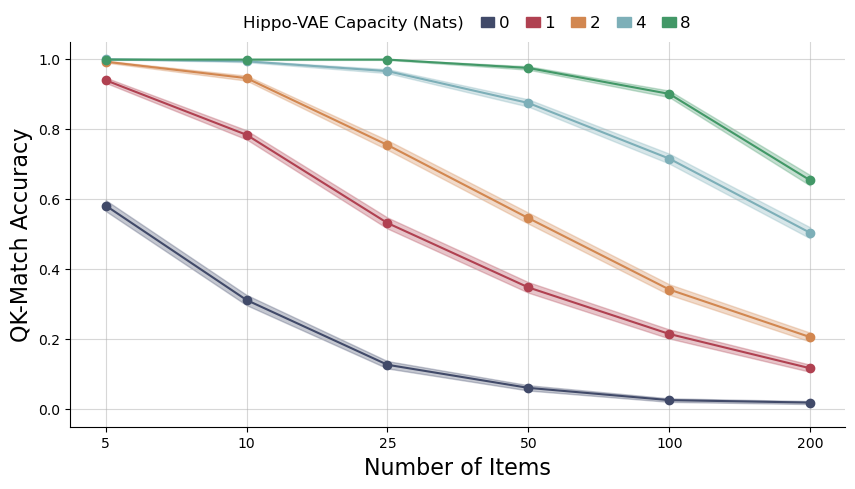

In [21]:
fig, ax = plt.subplots(figsize=(10,5))

colors = ["#414a69", "#b04151", "#d28750", "#7dafb8", "#429867"]
palette = {k:v for k,v in zip(Cs, colors)}

for memory_capacity in data.memory_capacity.unique():
    df = data.query(f"memory_capacity=={memory_capacity}")
    mean = df.groupby("n_items").guess.mean().values
    se = df.groupby("n_items").guess.apply(lambda x: x.std()/np.sqrt(x.size)).values

    ax.plot(np.arange(len(mean)), mean, "o-", label=memory_capacity, color=palette[memory_capacity])
    ax.fill_between(np.arange(len(mean)), mean-se, mean+se, alpha=0.3, color=palette[memory_capacity])

ax.set_xticks(np.arange(len(mean)), labels=Ns)
ax.grid(True, alpha=0.5)
ax.set_xlabel("Number of Items", fontsize=16)
ax.set_ylabel("QK-Match Accuracy", fontsize=16)
ax.set_ylim(-0.05,1.05)

legend = ax.legend(
    handles=[Patch(color="none", label="Hippo-VAE Capacity (Nats)")] + [Patch(color=v, label=k) for k,v in palette.items()],
    loc="center",
    ncol=6,
    handlelength=1,
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.3,
)
for text in legend.get_texts():
    text.set_fontsize(12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [22]:
fig.savefig("visuals/old_new_k3.pdf")

Text(0.025, 0.19, 'Embedding Recon.')

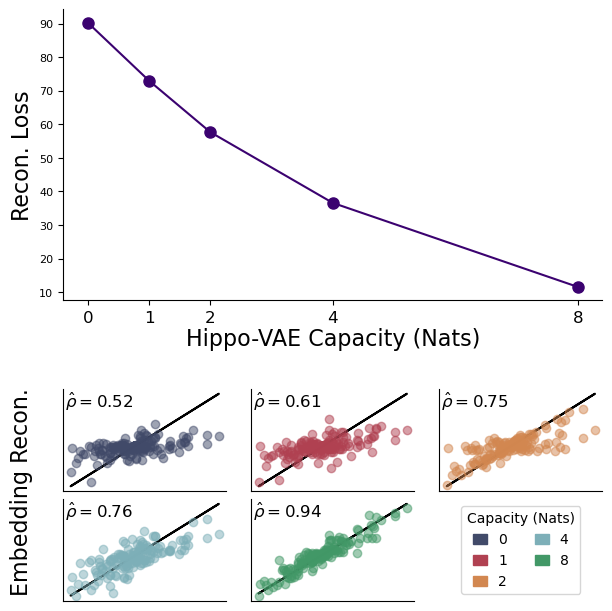

In [25]:
fig = plt.figure(figsize=(6,6), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=5,
    ncols=3,
    height_ratios=[1,1,0.15,0.7,0.7]
)

ax = fig.add_subplot(gs[2,:])
ax.axis("off")


ax = fig.add_subplot(gs[:2,:])
ax.plot(Cs, [ckpts[i]["rec_loss"] for i in Cs], "o-", color="#3B0270", markersize=8)
ax.set_xticks(Cs)
ax.set_xlabel("Hippo-VAE Capacity (Nats)", fontsize=16, labelpad=2)
ax.set_ylabel("Recon. Loss", fontsize=16)
ax.set_xticklabels(Cs, fontsize=12)
ax.tick_params(axis="y", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


x = test_dataset.X[0]
while True:
    recs = []
    rhos = []
    for C in Cs:
        m = load_model(ckpts[C])
        rec = get_latent(m, x[None])[0]
        recs.append(rec)
        rho = np.corrcoef(x,rec)[0,1]
        rhos.append(rho)
    
    if np.diff(np.array(rhos)).prod() > 0:
        break
c = 0
for i in range(2):
    for j in range(3):
        if (i==1) & (j==2): continue
        
        ax = fig.add_subplot(gs[i+3, j])

        C = Cs[c]
        rec = recs[c]

        ax.plot(x,x,"k-")
        ax.plot(x,rec,"o",color=palette[C], alpha=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        text = fr"$\hat\rho={np.corrcoef(x,rec)[0,1].round(2)}$"
        ax.text(
            0.01, 0.99,         
            text,        
            transform=ax.transAxes,   
            va="top", ha="left",    
            fontsize=12,
        )
        c += 1
ax = fig.add_subplot(gs[4, 2])
ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")
ax.legend(
    handles=[Patch(color=v, label=k) for k,v in palette.items()],
    title="Capacity (Nats)",
    loc="center",
    ncol=2,
    handlelength=1
)

fig.text(
    0.025, 0.19,
    "Embedding Recon.",
    va="center", ha="center",
    rotation="vertical",
    fontsize=16
)

In [27]:
fig.savefig("visuals/hippo_vae-embed_corr.pdf")